# TT-17 — Random Forest Regressor: Dự đoán giá vé máy bay

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RANDOM_STATE = 42
sns.set_style("whitegrid")

## Bước 1 — Nạp dữ liệu, bỏ cột thừa

In [2]:
df = pd.read_csv("../dataset/Clean_Dataset.csv")
df = df.drop(columns=["Unnamed: 0", "flight"], errors="ignore")
print(df.shape)
df.head()

(300153, 10)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Bước 2 — EDA: giá theo `days_left`

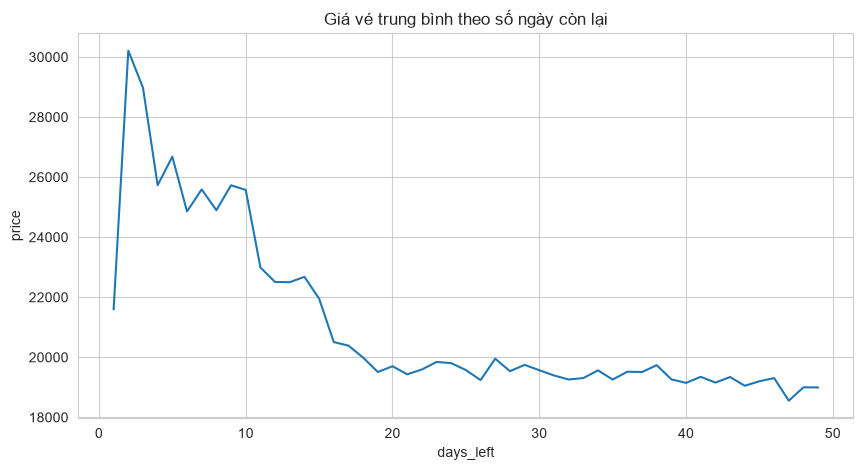

In [3]:
gia_tb = df.groupby("days_left")["price"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=gia_tb, x="days_left", y="price")
plt.title("Giá vé trung bình theo số ngày còn lại")
plt.show()

## Bước 3 — EDA: boxplot theo `class` và `airline`

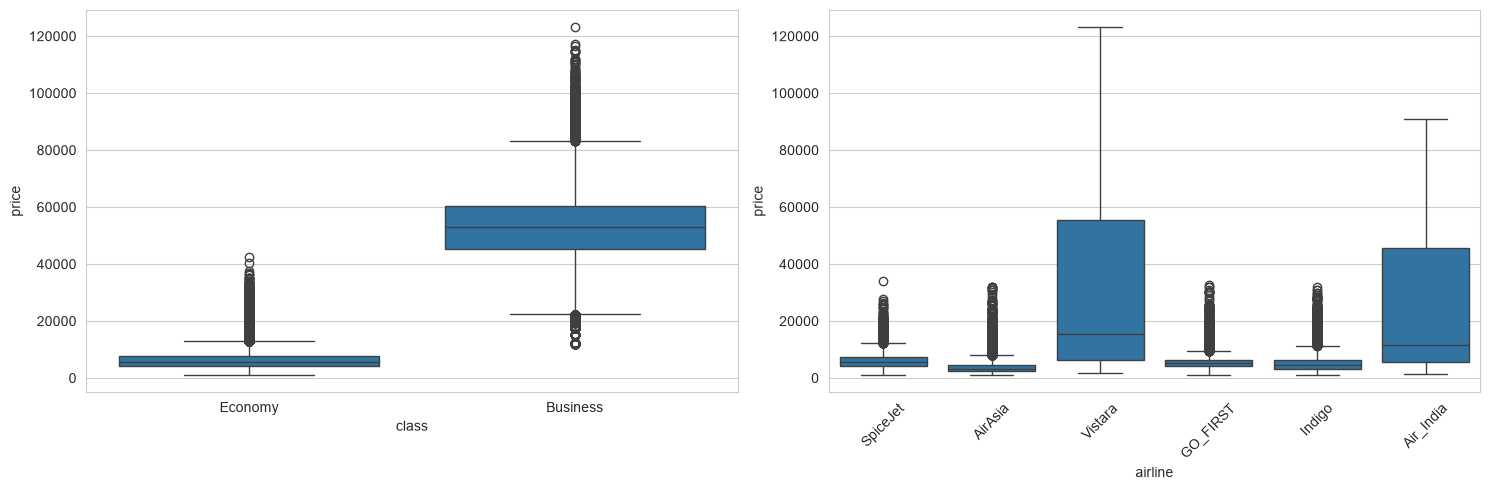

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=df, x="class", y="price", ax=ax[0])
sns.boxplot(data=df, x="airline", y="price", ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Bước 4 — Pipeline tiền xử lý

In [5]:
cot_phan_loai = ["airline", "source_city", "departure_time", "stops",
                 "arrival_time", "destination_city", "class"]
cot_so = ["duration", "days_left"]

tien_xu_ly = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cot_phan_loai)],
    remainder="passthrough"
)

X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## Bước 5 — Baseline: Dummy + Linear + 1 cây đơn

In [6]:
for ten, model in [
    ("Dummy", DummyRegressor(strategy="mean")),
    ("Linear Regression", LinearRegression()),
    ("Cây đơn (TT-16)", DecisionTreeRegressor(random_state=RANDOM_STATE)),
]:
    pipe = Pipeline([("prep", tien_xu_ly), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{ten:20s} RMSE={rmse:,.0f}  R²={r2_score(y_test, pred):.4f}")

Dummy                RMSE=22,704  R²=-0.0000
Linear Regression    RMSE=6,762  R²=0.9113
Cây đơn (TT-16)      RMSE=3,532  R²=0.9758


## Bước 6 — Random Forest + `oob_score_`

In [7]:
rf = RandomForestRegressor(
    n_estimators=300, max_features=1.0, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE, oob_score=True,
)
pipe_rf = Pipeline([("prep", tien_xu_ly), ("model", rf)])
pipe_rf.fit(X_train, y_train)

print("OOB score:", pipe_rf.named_steps["model"].oob_score_)
pred_rf = pipe_rf.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R²:", r2_score(y_test, pred_rf))

joblib.dump(pipe_rf, "../models/rf_reg.joblib")

OOB score: 0.9863674248153866
RMSE: 2694.4205087685245
R²: 0.9859162918875766


['../models/rf_reg.joblib']

## Bước 7 — RMSE theo số cây

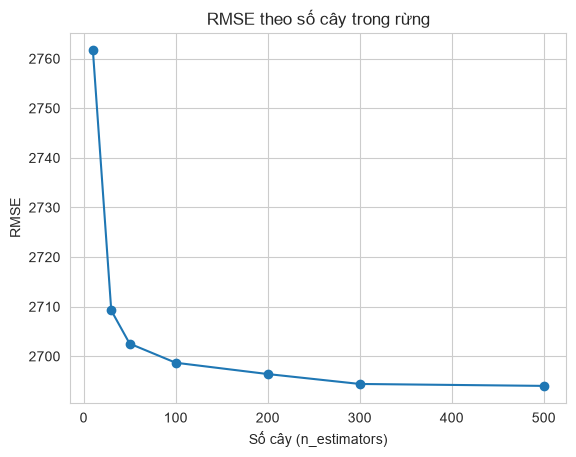

In [8]:
so_cay_list = [10, 30, 50, 100, 200, 300, 500]
rmse_list = []
for n in so_cay_list:
    rf_tmp = RandomForestRegressor(n_estimators=n, max_features=1.0,
                                     min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE)
    p = Pipeline([("prep", tien_xu_ly), ("model", rf_tmp)])
    p.fit(X_train, y_train)
    pred = p.predict(X_test)
    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.plot(so_cay_list, rmse_list, marker="o")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("RMSE")
plt.title("RMSE theo số cây trong rừng")
plt.show()

## Bước 8 — Permutation importance

In [9]:
ket_qua = permutation_importance(pipe_rf, X_test, y_test, n_repeats=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": ket_qua.importances_mean
}).sort_values("importance_mean", ascending=False)
importance_df

,feature,importance_mean
6,class,1.722362
7,duration,0.143605
0,airline,0.049334
1,source_city,0.047555
5,destination_city,0.047311
8,days_left,0.030636
4,arrival_time,0.016444
2,departure_time,0.012269
3,stops,0.007889


## Bước 9 — PDP cho `days_left`

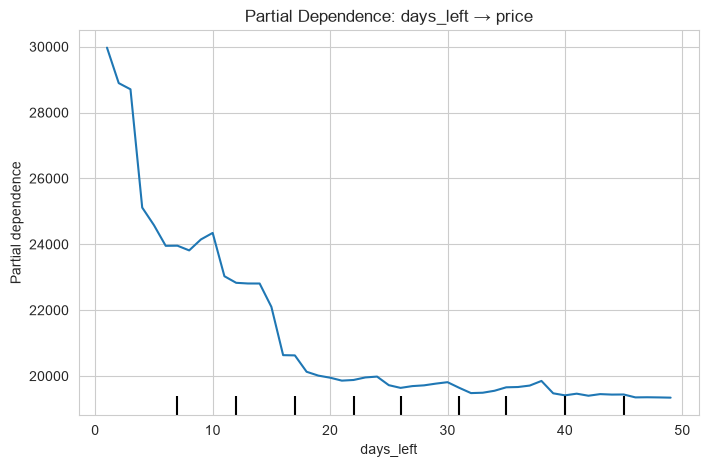

In [10]:
X_train_float = X_train.copy()
X_train_float["days_left"] = X_train_float["days_left"].astype(float)

fig, ax = plt.subplots(figsize=(8,5))
PartialDependenceDisplay.from_estimator(pipe_rf, X_train_float, features=["days_left"], ax=ax)
plt.title("Partial Dependence: days_left → price")
plt.show()

## Bước 10 — Khoảng dự báo 10–90%

In [11]:
X_test_transformed = pipe_rf.named_steps["prep"].transform(X_test)
du_doan_tung_cay = np.stack([cay.predict(X_test_transformed) for cay in pipe_rf.named_steps["model"].estimators_])
khoang_thap = np.percentile(du_doan_tung_cay, 10, axis=0)
khoang_cao  = np.percentile(du_doan_tung_cay, 90, axis=0)

trong_khoang = ((y_test.values >= khoang_thap) & (y_test.values <= khoang_cao)).mean()
print(f"Tỉ lệ phủ thực tế: {trong_khoang:.1%}")

Tỉ lệ phủ thực tế: 86.5%


## Bước 11 — Thí nghiệm ngoại suy

In [12]:
mau = X_test.iloc[[0]].copy()
for dl in [X_test["days_left"].max(), 100, 500]:
    mau["days_left"] = dl
    print(f"days_left={dl}: giá dự đoán = {pipe_rf.predict(mau)[0]:,.0f}")

days_left=49: giá dự đoán = 7,304
days_left=100: giá dự đoán = 7,304
days_left=500: giá dự đoán = 7,304


## Bước 12 — So sánh với XGBoost

In [13]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                     random_state=RANDOM_STATE, n_jobs=-1)
pipe_xgb = Pipeline([("prep", tien_xu_ly), ("model", xgb)])
pipe_xgb.fit(X_train, y_train)
pred_xgb = pipe_xgb.predict(X_test)
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("XGBoost R²:", r2_score(y_test, pred_xgb))

XGBoost RMSE: 3459.7660325519123
XGBoost R²: 0.976779043674469
